# MPPP Processing

An Image object represents an image, processing would be done using the image array amd metadata stored as attributes in the image object. If the image is processed, the processed array could be accessed throught the attribute ```.im8``` of the image object.


An ImProcessor represents and image processor object. It is initiated by providing it with a json config file. An example file could be found in ```./params/image_processing_config.json```. To process a list of images, use the function ```process_images()```.

First initialise a processor object by passing in a file path to the json config file for the processor. This config file should specify the file_extension, boolean flags for saving the different components, lower bound clip values and scales used.

In [1]:
from src2.Image import Image, Frame
from src2.ImProcessor import ImProcessor

# create a processor object
processor = ImProcessor("./params/image_processing_config.json")

Finds all the files that corresponds to the target sol and process by every 10 sols. To process all the images, provide a list of file paths, the output directory to save the processed images and the suffix to be used in naming the output csv file

Processing Sols 10** in ../data/zcam
2761 images

Number of images: 2761
0 opened ZL0_1000_0755710960_331RAD_N0474374ZCAM09012_1100LMA01.IMG
saved ../images/sols_1000-1099_sci/ZL0_1000_0755710960_331RAD_N0474374ZCAM09012_1100LMA01.png
1 opened ZL0_1000_0755711105_488RAD_N0474374ZCAM09013_1100LMA01.IMG
saved ../images/sols_1000-1099_sci/ZL0_1000_0755711105_488RAD_N0474374ZCAM09013_1100LMA01.png
2 opened ZL0_1000_0755711136_269RAD_N0474374ZCAM03830_0340LMA01.IMG
saved ../images/sols_1000-1099_sci/ZL0_1000_0755711136_269RAD_N0474374ZCAM03830_0340LMA01.png
3 opened ZL0_1000_0755711504_053RAD_N0474374ZCAM03020_0480LMA01.IMG
saved ../images/sols_1000-1099_sci/ZL0_1000_0755711504_053RAD_N0474374ZCAM03020_0480LMA01.png
4 opened ZL0_1000_0755711547_928RAD_N0474374ZCAM03831_0630LMA01.IMG
saved ../images/sols_1000-1099_sci/ZL0_1000_0755711547_928RAD_N0474374ZCAM03831_0630LMA01.png
5 opened ZL0_1000_0755728248_784RAD_N0474404ZCAM00037_1100LMA01.IMG
saved ../images/sols_1000-1099_sci/ZL0_1000_07557

z:\Mastcam-Z\agisoft\MPPP\.venv\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
z:\Mastcam-Z\agisoft\MPPP\.venv\lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
z:\Mastcam-Z\agisoft\MPPP\.venv\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Processing Sols 10** in ../data/datadrive
117 images

Number of images: 117
0 opened FLF_1018_0757321418_112RAD_N0483714FHAZ02418_0A0295J01.IMG
saved ../images/sols_1000-1099_eng/FLF_1018_0757321418_112RAD_N0483714FHAZ02418_0A0295J01.png
1 opened FLF_1019_0757406970_645RAD_N0490000FHAZ02418_0A0295J01.IMG
saved ../images/sols_1000-1099_eng/FLF_1019_0757406970_645RAD_N0490000FHAZ02418_0A0295J01.png
2 opened FLF_1031_0758485090_675RAD_N0490370FHAZ02009_0A2095J02.IMG
saved ../images/sols_1000-1099_eng/FLF_1031_0758485090_675RAD_N0490370FHAZ02009_0A2095J02.png
3 opened FLF_1032_0758565895_005RAD_N0490370FHAZ02418_0A0295J01.IMG
saved ../images/sols_1000-1099_eng/FLF_1032_0758565895_005RAD_N0490370FHAZ02418_0A0295J01.png
4 opened FLF_1033_0758635668_691RAD_N0490370FHAZ02418_0A0295J01.IMG
saved ../images/sols_1000-1099_eng/FLF_1033_0758635668_691RAD_N0490370FHAZ02418_0A0295J01.png
5 opened FLF_1035_0758841943_316RAD_N0490370FHAZ02009_0A0095J01.IMG
saved ../images/sols_1000-1099_eng/FLF_1035_07

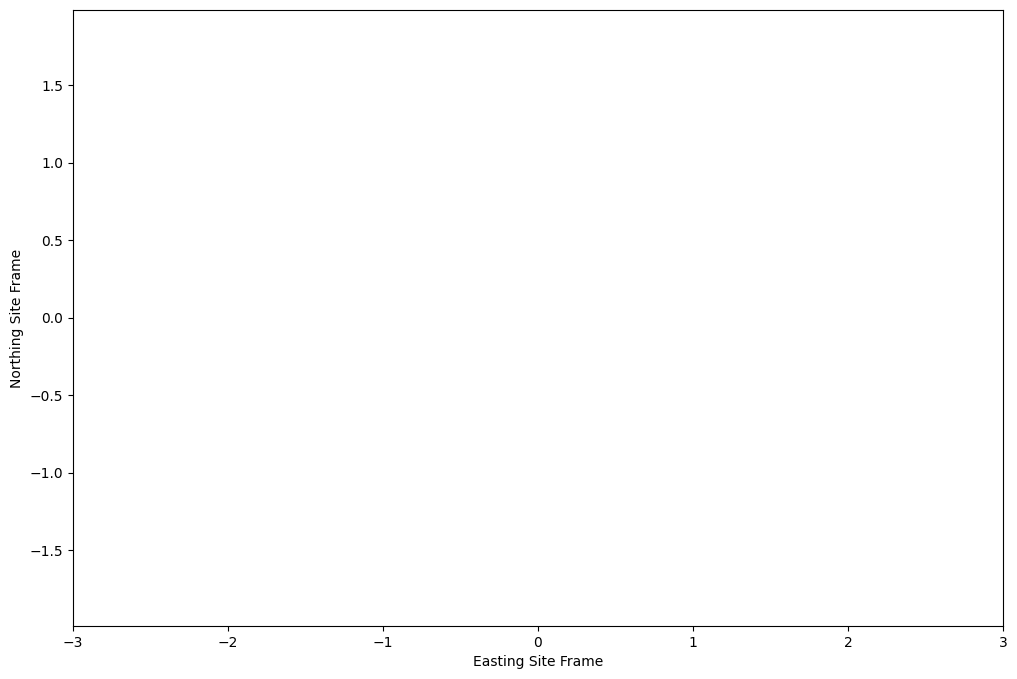

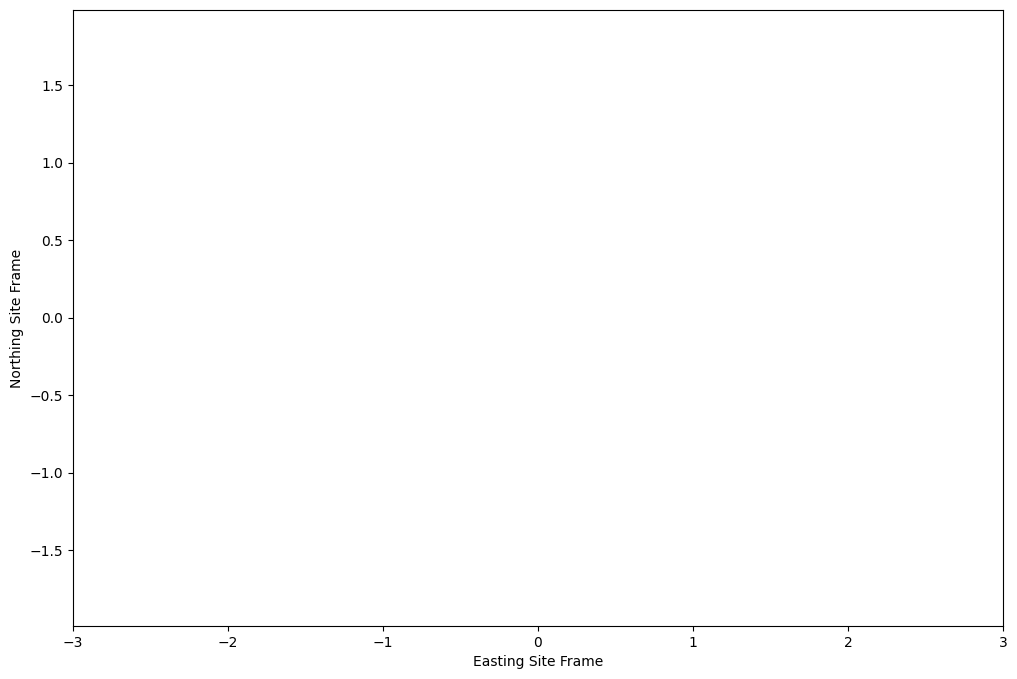

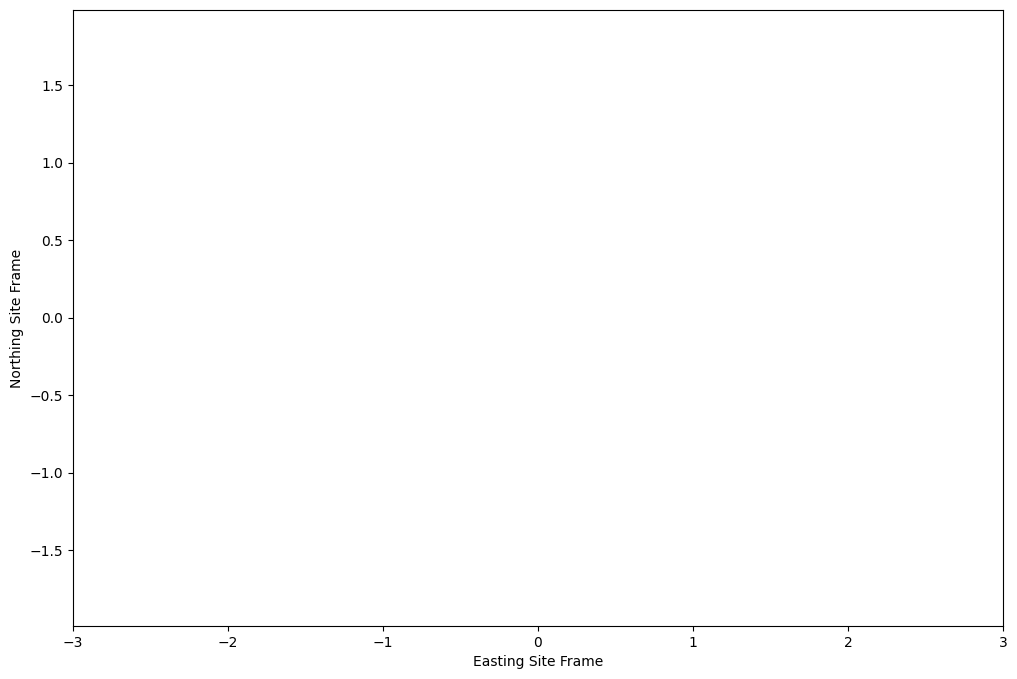

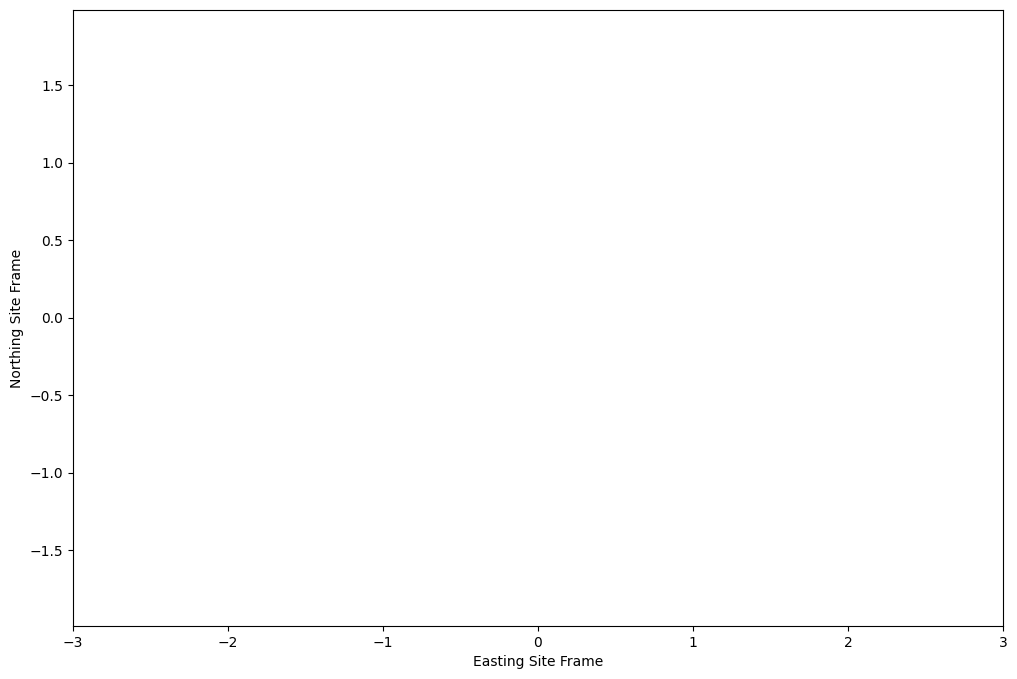

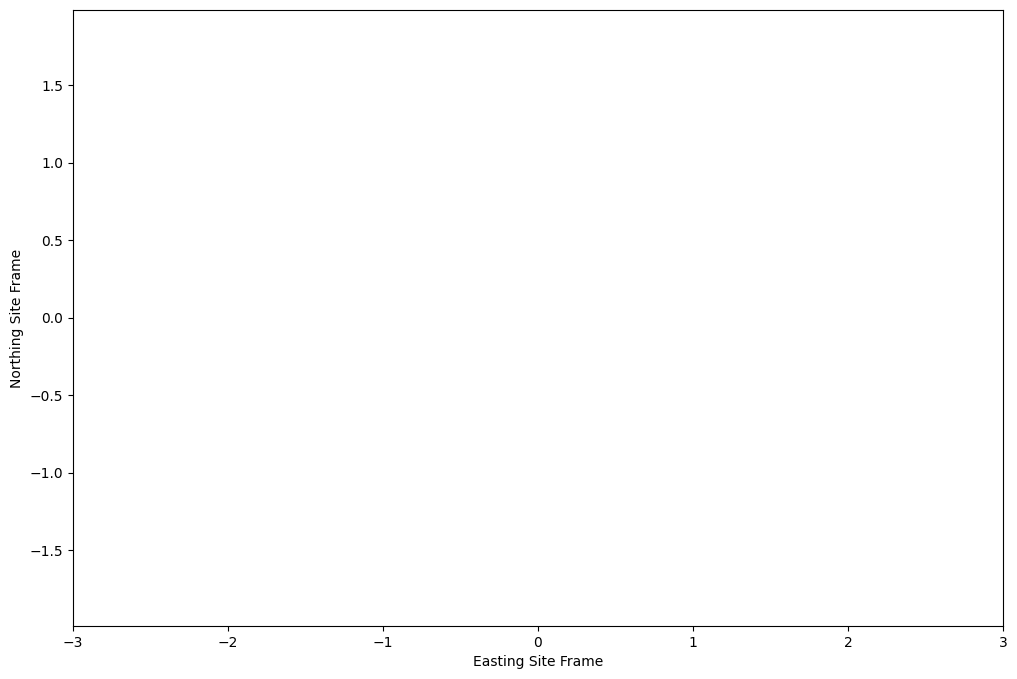

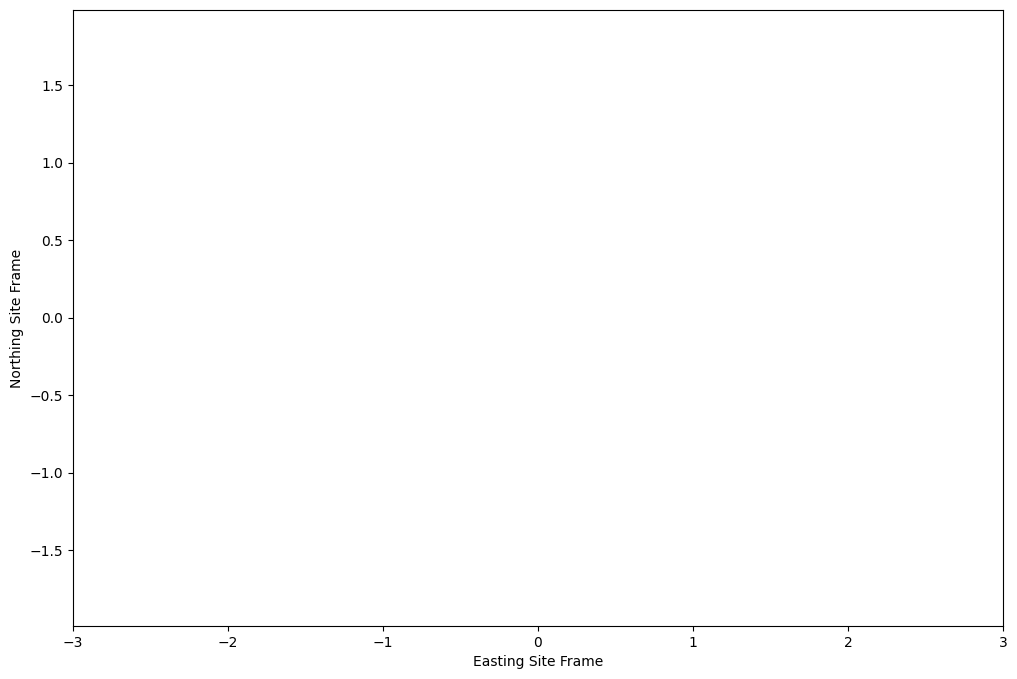

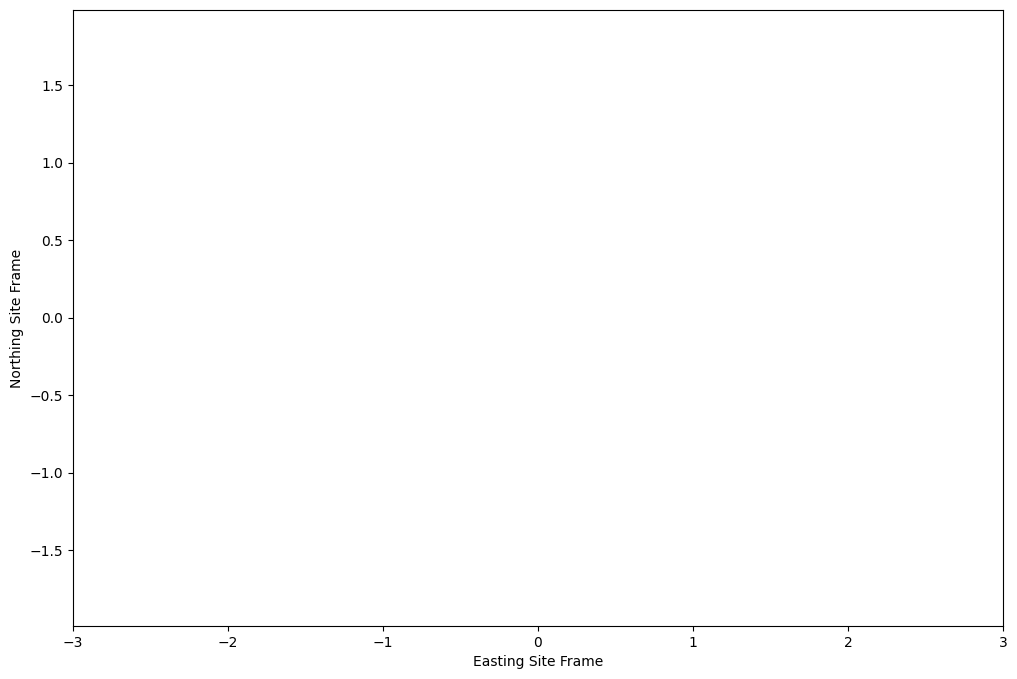

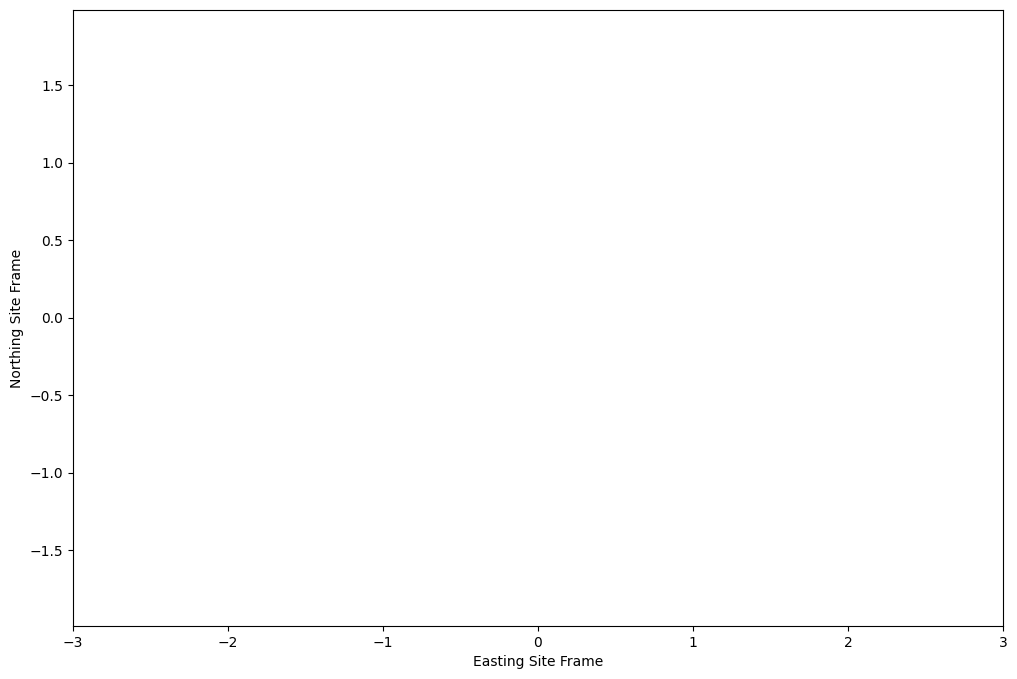

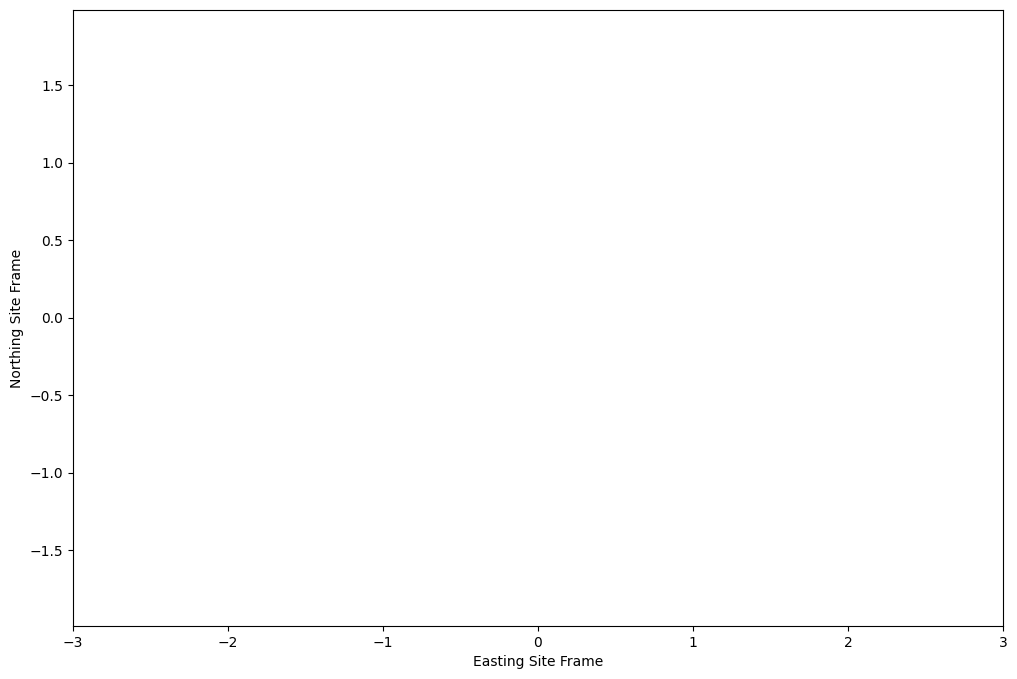

In [2]:
import glob


directory_output =  '../data/cal'
directory_output =  '../images'

IMG_paths = []
directory_inputs = ['../data/zcam', '../data/datadrive', '../data/datadrive/*/*/*/*']
sols = ['10*', '11*', '12*']

for sol in sols:
    for directory_input in directory_inputs:
        print(f"Processing Sols {sol}* in {directory_input}")
        try:
            IMG_paths = []
            suf = 'refs_'+str(sol)
            
            IMG_paths     += sorted( glob.glob(directory_input + f"/FLF_{sol}_*.IMG"))
            IMG_paths     += sorted( glob.glob(directory_input + f"/FRF_{sol}_*.IMG"))
            IMG_paths     += sorted( glob.glob(directory_input + f"/NLF_{sol}_*.IMG"))
            # IMG_paths     += sorted( glob.glob(directory_input + f"/NLMV_{sol}*_*.IMG"))
            IMG_paths     += sorted( glob.glob(directory_input + f"/NRF_{sol}_*.IMG"))
            # IMG_paths     += sorted( glob.glob(directory_input + f"/NRMV_{sol}*_*.IMG"))
            IMG_paths     += sorted( glob.glob(directory_input + f"/*/ZL0_{sol}_*.IMG"))
            IMG_paths     += sorted( glob.glob(directory_input + f"/*/ZR0_{sol}_*.IMG"))
        
            IMG_paths = IMG_paths[:]
            print( len(IMG_paths), 'images\n')
            if len(IMG_paths):
                processor.process_images(img_paths = IMG_paths,
                                    output_dir = directory_output,
                                    suf = suf.replace('*',''),
                                    find_offset_mode=False,
                                    frame = "site",
                                    angles = 'opk',
                                    save_im = True)
        except:
            print(f"FAILED TO PROCESS! sols:{sol}* in {directory_input}")

        print("="*100)